# 5. Model Building & Training
## Hybrid Machine Learning Framework for Chronic Kidney Disease Prediction

### Objective
Build and train multiple machine-learning classification models for Chronic
Kidney Disease (CKD) prediction using the preprocessed feature pipeline.

### Models
1. Logistic Regression — Baseline
2. Decision Tree
3. K-Nearest Neighbors (KNN)
4. Support Vector Machine (SVM)
5. Random Forest
6. AdaBoost
7. Gradient Boosting
8. XGBoost
9. LightGBM

### Methodology
- Use the original CKD CSV as the source dataset.
- Keep the target column `class` separate from the predictors.
- Use an 80:20 stratified train-test split.
- Apply median imputation + StandardScaler to numerical features.
- Apply most-frequent imputation + One-Hot Encoding to categorical features.
- Keep preprocessing inside each model Pipeline to avoid data leakage.
- Train every available model using the same training partition.
- Use 5-fold Stratified Cross-Validation on the training partition.
- Save model-building results for the later tuning, evaluation, comparison,
  and results-dashboard stages.

> This notebook is an academic machine-learning prototype. It is not a
> clinically validated diagnostic system.


## 1. Import Libraries

In [1]:
import sys

print("Python executable:")
print(sys.executable)

print("\nPython version:")
print(sys.version)

Python executable:
c:\Users\Arnav\OneDrive\Desktop\KLH\2year\Machine Learning\Hybrid_ML_CKD_Prediction\CKD.venv\Scripts\python.exe

Python version:
3.14.3 (tags/v3.14.3:323c59a, Feb  3 2026, 16:04:56) [MSC v.1944 64 bit (AMD64)]


In [2]:
import os
from pathlib import Path
import warnings
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Locate and Load the Original CKD Dataset

In [3]:
# The notebook is expected to be inside:
# source_dataset/notebooks/
#
# We first try the normal relative path. If it is not found, we search
# nearby project folders for a CSV with exactly 25 columns and a `class`
# target column.

preferred_paths = [
    Path("../chronic_kidney_disease.csv"),
    Path("../../dataset/raw/chronic_kidney_disease.csv"),
    Path("../dataset/raw/chronic_kidney_disease.csv"),
    Path("/mnt/data/chronic_kidney_disease.csv"),
]

DATA_PATH = None

for candidate in preferred_paths:
    if candidate.exists():
        try:
            test_df = pd.read_csv(candidate)
            if "class" in test_df.columns and test_df.shape[1] == 25:
                DATA_PATH = candidate
                break
        except Exception:
            pass

# If the preferred paths did not work, search the project area.
if DATA_PATH is None:
    search_roots = [
        Path(".").resolve(),
        Path("..").resolve(),
        Path("/mnt/data")
    ]

    matches = []
    for root in search_roots:
        if root.exists():
            for p in root.rglob("chronic_kidney_disease.csv"):
                if "notebook" in str(p).lower():
                    continue
                try:
                    test_df = pd.read_csv(p)
                    if "class" in test_df.columns and test_df.shape[1] == 25:
                        matches.append(p)
                except Exception:
                    continue

    if matches:
        # Prefer a file whose name is exactly the raw CSV and whose
        # dimensions are 400 x 25.
        exact_raw = [p for p in matches if pd.read_csv(p, nrows=1).shape[1] == 25]
        DATA_PATH = exact_raw[0] if exact_raw else matches[0]

if DATA_PATH is None:
    raise FileNotFoundError(
        "Original chronic_kidney_disease.csv was not found. "
        "Place the 400 x 25 original CSV in the project dataset folder."
    )

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Dataset path:", DATA_PATH)
print("Dataset shape:", df.shape)

assert df.shape[1] == 25, (
    f"Expected 25 columns (24 predictors + class), but found {df.shape[1]}."
)
assert "class" in df.columns, "Target column `class` is missing."

print("Dataset structure check passed.")

Dataset loaded successfully.
Dataset path: ..\..\dataset\raw\chronic_kidney_disease.csv
Dataset shape: (400, 25)
Dataset structure check passed.


## 3. Basic Dataset Verification

In [4]:
df.columns = df.columns.str.strip()

print("First 5 records:")
display(df.head())

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset shape:")
print(df.shape)

print("\nTarget values before encoding:")
print(df["class"].astype(str).str.strip().str.lower().value_counts())

print("\nTotal missing cells:")
print(df.isnull().sum().sum())

First 5 records:


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38.0,6000.0,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31.0,7500.0,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35.0,7300.0,4.6,no,no,no,good,no,no,ckd



Column names:
['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wbcc', 'rbcc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'class']

Dataset shape:
(400, 25)

Target values before encoding:
class
ckd       250
notckd    150
Name: count, dtype: int64

Total missing cells:
1012


## 4. Prepare the Target Variable

In [5]:
# Convert the target to binary labels:
# CKD     -> 1
# NOTCKD  -> 0

df["class"] = (
    df["class"]
    .astype(str)
    .str.strip()
    .str.lower()
)

target_mapping = {
    "ckd": 1,
    "notckd": 0
}

df["class"] = df["class"].map(target_mapping)

# Target values should be valid after mapping.
if df["class"].isnull().any():
    invalid_count = df["class"].isnull().sum()
    raise ValueError(
        f"{invalid_count} target value(s) could not be mapped. "
        "Check the original `class` values."
    )

df["class"] = df["class"].astype(int)

print("Target encoding completed.")
print("\nEncoded target distribution:")
print(df["class"].value_counts().sort_index())

print("\nTarget labels:")
print("0 = notckd")
print("1 = ckd")

Target encoding completed.

Encoded target distribution:
class
0    150
1    250
Name: count, dtype: int64

Target labels:
0 = notckd
1 = ckd


## 5. Separate Predictors and Target

In [6]:
X = df.drop(columns=["class"])
y = df["class"]

print("Predictor matrix X:", X.shape)
print("Target vector y:", y.shape)

assert X.shape[1] == 24, (
    f"Expected 24 predictor columns, but found {X.shape[1]}."
)

print("Predictor/target separation check passed.")

Predictor matrix X: (400, 24)
Target vector y: (400,)
Predictor/target separation check passed.


## 6. Define Numerical and Categorical Features

In [7]:
numeric_features = [
    "age",
    "bp",
    "sg",
    "al",
    "su",
    "bgr",
    "bu",
    "sc",
    "sod",
    "pot",
    "hemo",
    "pcv",
    "wbcc",
    "rbcc"
]

categorical_features = [
    "rbc",
    "pc",
    "pcc",
    "ba",
    "htn",
    "dm",
    "cad",
    "appet",
    "pe",
    "ane"
]

all_declared_features = numeric_features + categorical_features

missing_from_dataset = [
    col for col in all_declared_features if col not in X.columns
]

unexpected_features = [
    col for col in X.columns if col not in all_declared_features
]

if missing_from_dataset:
    raise ValueError(f"Features missing from dataset: {missing_from_dataset}")

if unexpected_features:
    raise ValueError(f"Unexpected predictor columns found: {unexpected_features}")

print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Total predictors:", len(all_declared_features))

Numerical features: 14
Categorical features: 10
Total predictors: 24


## 7. Stratified Train-Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining class counts:")
print(y_train.value_counts().sort_index())

print("\nTesting class counts:")
print(y_test.value_counts().sort_index())

print("\nTraining class proportions:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nTesting class proportions:")
print(y_test.value_counts(normalize=True).sort_index())

Training samples: 320
Testing samples: 80

Training class counts:
class
0    120
1    200
Name: count, dtype: int64

Testing class counts:
class
0    30
1    50
Name: count, dtype: int64

Training class proportions:
class
0    0.375
1    0.625
Name: proportion, dtype: float64

Testing class proportions:
class
0    0.375
1    0.625
Name: proportion, dtype: float64


## 8. Leakage-Safe Preprocessing Pipeline

In [9]:
# Numerical features:
# 1. Median imputation
# 2. StandardScaler
#
# Categorical features:
# 1. Most-frequent imputation
# 2. One-Hot Encoding

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")
print("Numerical: median imputation + StandardScaler")
print("Categorical: most-frequent imputation + OneHotEncoder")

Preprocessing pipeline created successfully.
Numerical: median imputation + StandardScaler
Categorical: most-frequent imputation + OneHotEncoder


## 9. Define the Core Machine-Learning Models

In [10]:
models = {
    # Baseline
    "Logistic Regression": LogisticRegression(
        C=1.0,
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=7,
        weights="distance"
    ),

    "SVM": SVC(
        C=1.0,
        kernel="rbf",
        gamma="scale",
        probability=True,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    ),

    "AdaBoost": AdaBoostClassifier(
        n_estimators=100,
        learning_rate=0.5,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=3,
        min_samples_split=5,
        min_samples_leaf=2,
        subsample=0.9,
        random_state=42
    )
}

print("Core models defined:")
for number, name in enumerate(models, start=1):
    print(f"{number}. {name}")

Core models defined:
1. Logistic Regression
2. Decision Tree
3. KNN
4. SVM
5. Random Forest
6. AdaBoost
7. Gradient Boosting


## 10. Add XGBoost

In [11]:
try:
    from xgboost import XGBClassifier

    models["XGBoost"] = XGBClassifier(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        min_child_weight=2,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

    print("XGBoost added successfully.")

except ImportError:
    print("XGBoost is not installed.")
    print("Install in CKD.venv using: pip install xgboost")

XGBoost added successfully.


## 11. Add LightGBM

In [12]:
try:
    from lightgbm import LGBMClassifier

    models["LightGBM"] = LGBMClassifier(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        num_leaves=15,
        min_child_samples=10,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1,
        random_state=42,
        verbosity=-1,
        n_jobs=-1
    )

    print("LightGBM added successfully.")

except ImportError:
    print("LightGBM is not installed.")
    print("Install in CKD.venv using: pip install lightgbm")

LightGBM added successfully.


## 12. Create a Common Pipeline for Every Model

In [13]:
model_pipelines = {}

for name, model in models.items():
    model_pipelines[name] = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

print("Model pipelines created successfully.")
print("\nModels available for training:")
for number, name in enumerate(model_pipelines, start=1):
    print(f"{number}. {name}")

Model pipelines created successfully.

Models available for training:
1. Logistic Regression
2. Decision Tree
3. KNN
4. SVM
5. Random Forest
6. AdaBoost
7. Gradient Boosting
8. XGBoost
9. LightGBM


## 13. Train All Models

In [14]:
trained_models = {}

for name, pipeline in model_pipelines.items():
    print(f"Training: {name}")

    pipeline.fit(
        X_train,
        y_train
    )

    trained_models[name] = pipeline

print("\nAll available models trained successfully.")
print("Number of trained models:", len(trained_models))

Training: Logistic Regression
Training: Decision Tree
Training: KNN
Training: SVM
Training: Random Forest
Training: AdaBoost
Training: Gradient Boosting
Training: XGBoost
Training: LightGBM

All available models trained successfully.
Number of trained models: 9


## 14. Training-Set Performance

In [15]:
training_results = []

for name, pipeline in trained_models.items():

    y_pred = pipeline.predict(X_train)

    result = {
        "Model": name,
        "Training Accuracy": accuracy_score(y_train, y_pred),
        "Training Precision": precision_score(y_train, y_pred, zero_division=0),
        "Training Recall": recall_score(y_train, y_pred, zero_division=0),
        "Training F1-Score": f1_score(y_train, y_pred, zero_division=0)
    }

    try:
        y_prob = pipeline.predict_proba(X_train)[:, 1]
        result["Training ROC-AUC"] = roc_auc_score(y_train, y_prob)
    except Exception:
        result["Training ROC-AUC"] = np.nan

    training_results.append(result)

training_results_df = pd.DataFrame(training_results)

display(
    training_results_df.sort_values(
        "Training Accuracy",
        ascending=False
    ).reset_index(drop=True)
)

,Model,Training Accuracy,Training Precision,Training Recall,Training F1-Score,Training ROC-AUC
0,Logistic Regression,1.000000,1.000000,1.0,1.000000,1.000000
1,KNN,1.000000,1.000000,1.0,1.000000,1.000000
2,SVM,1.000000,1.000000,1.0,1.000000,1.000000
3,Random Forest,1.000000,1.000000,1.0,1.000000,1.000000
4,AdaBoost,1.000000,1.000000,1.0,1.000000,1.000000
5,LightGBM,1.000000,1.000000,1.0,1.000000,1.000000
6,Gradient Boosting,1.000000,1.000000,1.0,1.000000,1.000000
7,XGBoost,0.996875,0.995025,1.0,0.997506,1.000000
8,Decision Tree,0.990625,0.985222,1.0,0.992556,0.999333


## 15. Five-Fold Stratified Cross-Validation

Cross-validation is performed **only on the training partition**. The final
test partition remains untouched for the later evaluation stage.


In [16]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

for name, pipeline in model_pipelines.items():

    print(f"Cross-validating: {name}")

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "CV Mean Accuracy": scores.mean(),
        "CV Std": scores.std(),
        "CV Fold 1": scores[0],
        "CV Fold 2": scores[1],
        "CV Fold 3": scores[2],
        "CV Fold 4": scores[3],
        "CV Fold 5": scores[4]
    })

cv_results_df = pd.DataFrame(cv_results)

display(
    cv_results_df.sort_values(
        "CV Mean Accuracy",
        ascending=False
    ).reset_index(drop=True)
)

Cross-validating: Logistic Regression
Cross-validating: Decision Tree
Cross-validating: KNN
Cross-validating: SVM
Cross-validating: Random Forest
Cross-validating: AdaBoost
Cross-validating: Gradient Boosting
Cross-validating: XGBoost
Cross-validating: LightGBM


,Model,CV Mean Accuracy,CV Std,CV Fold 1,CV Fold 2,CV Fold 3,CV Fold 4,CV Fold 5
0,SVM,0.996875,0.006250,1.000000,1.000000,1.000000,1.000000,0.984375
1,Logistic Regression,0.993750,0.007655,1.000000,1.000000,0.984375,0.984375,1.000000
2,Random Forest,0.990625,0.007655,1.000000,0.984375,0.984375,0.984375,1.000000
3,AdaBoost,0.990625,0.012500,1.000000,0.984375,0.968750,1.000000,1.000000
4,LightGBM,0.984375,0.017116,0.984375,0.984375,0.953125,1.000000,1.000000
5,XGBoost,0.981250,0.018222,1.000000,0.984375,0.953125,0.968750,1.000000
6,Gradient Boosting,0.975000,0.027243,0.984375,0.984375,0.921875,0.984375,1.000000
7,KNN,0.962500,0.012500,0.953125,0.984375,0.953125,0.953125,0.968750
8,Decision Tree,0.953125,0.017116,0.937500,0.953125,0.953125,0.937500,0.984375


## 16. Combine Training and Cross-Validation Results

In [17]:
comparison_df = training_results_df.merge(
    cv_results_df,
    on="Model",
    how="inner"
)

comparison_df["Generalization Gap"] = (
    comparison_df["Training Accuracy"]
    - comparison_df["CV Mean Accuracy"]
)

comparison_df = comparison_df.sort_values(
    "CV Mean Accuracy",
    ascending=False
).reset_index(drop=True)

display(comparison_df)

,Model,Training Accuracy,Training Precision,Training Recall,Training F1-Score,Training ROC-AUC,CV Mean Accuracy,CV Std,CV Fold 1,CV Fold 2,CV Fold 3,CV Fold 4,CV Fold 5,Generalization Gap
0,SVM,1.000000,1.000000,1.0,1.000000,1.000000,0.996875,0.006250,1.000000,1.000000,1.000000,1.000000,0.984375,0.003125
1,Logistic Regression,1.000000,1.000000,1.0,1.000000,1.000000,0.993750,0.007655,1.000000,1.000000,0.984375,0.984375,1.000000,0.006250
2,Random Forest,1.000000,1.000000,1.0,1.000000,1.000000,0.990625,0.007655,1.000000,0.984375,0.984375,0.984375,1.000000,0.009375
3,AdaBoost,1.000000,1.000000,1.0,1.000000,1.000000,0.990625,0.012500,1.000000,0.984375,0.968750,1.000000,1.000000,0.009375
4,LightGBM,1.000000,1.000000,1.0,1.000000,1.000000,0.984375,0.017116,0.984375,0.984375,0.953125,1.000000,1.000000,0.015625
5,XGBoost,0.996875,0.995025,1.0,0.997506,1.000000,0.981250,0.018222,1.000000,0.984375,0.953125,0.968750,1.000000,0.015625
6,Gradient Boosting,1.000000,1.000000,1.0,1.000000,1.000000,0.975000,0.027243,0.984375,0.984375,0.921875,0.984375,1.000000,0.025000
7,KNN,1.000000,1.000000,1.0,1.000000,1.000000,0.962500,0.012500,0.953125,0.984375,0.953125,0.953125,0.968750,0.037500
8,Decision Tree,0.990625,0.985222,1.0,0.992556,0.999333,0.953125,0.017116,0.937500,0.953125,0.953125,0.937500,0.984375,0.037500


## 17. Generalization Warning

The following rule is only a **screening indicator**:
- Gap >= 0.05 → potential overfitting warning
- Both training and CV accuracy < 0.85 → possible underfitting warning
- Otherwise → no strong warning

These thresholds do not prove overfitting or underfitting. Detailed evaluation
and hyperparameter tuning are performed in later stages.


In [18]:
def generalization_status(row):
    gap = row["Generalization Gap"]

    if gap >= 0.05:
        return "Potential Overfitting"
    elif (
        row["Training Accuracy"] < 0.85
        and row["CV Mean Accuracy"] < 0.85
    ):
        return "Possible Underfitting"
    else:
        return "No Strong Warning"

generalization_df = comparison_df.copy()

generalization_df["Status"] = generalization_df.apply(
    generalization_status,
    axis=1
)

display(
    generalization_df[
        [
            "Model",
            "Training Accuracy",
            "CV Mean Accuracy",
            "CV Std",
            "Generalization Gap",
            "Status"
        ]
    ]
)

,Model,Training Accuracy,CV Mean Accuracy,CV Std,Generalization Gap,Status
0,SVM,1.000000,0.996875,0.006250,0.003125,No Strong Warning
1,Logistic Regression,1.000000,0.993750,0.007655,0.006250,No Strong Warning
2,Random Forest,1.000000,0.990625,0.007655,0.009375,No Strong Warning
3,AdaBoost,1.000000,0.990625,0.012500,0.009375,No Strong Warning
4,LightGBM,1.000000,0.984375,0.017116,0.015625,No Strong Warning
5,XGBoost,0.996875,0.981250,0.018222,0.015625,No Strong Warning
6,Gradient Boosting,1.000000,0.975000,0.027243,0.025000,No Strong Warning
7,KNN,1.000000,0.962500,0.012500,0.037500,No Strong Warning
8,Decision Tree,0.990625,0.953125,0.017116,0.037500,No Strong Warning


## 18. Dashboard-Ready Results Table

In [19]:
# Clean table for the future results dashboard.
# The dashboard should use actual values generated by this notebook.

dashboard_df = comparison_df[
    [
        "Model",
        "Training Accuracy",
        "Training Precision",
        "Training Recall",
        "Training F1-Score",
        "Training ROC-AUC",
        "CV Mean Accuracy",
        "CV Std",
        "Generalization Gap"
    ]
].copy()

display(dashboard_df)

,Model,Training Accuracy,Training Precision,Training Recall,Training F1-Score,Training ROC-AUC,CV Mean Accuracy,CV Std,Generalization Gap
0,SVM,1.000000,1.000000,1.0,1.000000,1.000000,0.996875,0.006250,0.003125
1,Logistic Regression,1.000000,1.000000,1.0,1.000000,1.000000,0.993750,0.007655,0.006250
2,Random Forest,1.000000,1.000000,1.0,1.000000,1.000000,0.990625,0.007655,0.009375
3,AdaBoost,1.000000,1.000000,1.0,1.000000,1.000000,0.990625,0.012500,0.009375
4,LightGBM,1.000000,1.000000,1.0,1.000000,1.000000,0.984375,0.017116,0.015625
5,XGBoost,0.996875,0.995025,1.0,0.997506,1.000000,0.981250,0.018222,0.015625
6,Gradient Boosting,1.000000,1.000000,1.0,1.000000,1.000000,0.975000,0.027243,0.025000
7,KNN,1.000000,1.000000,1.0,1.000000,1.000000,0.962500,0.012500,0.037500
8,Decision Tree,0.990625,0.985222,1.0,0.992556,0.999333,0.953125,0.017116,0.037500


### Suggested Results Dashboard

The final dashboard can contain:

- **KPI cards:** total models, training samples, test samples, CV folds
- **Model comparison chart:** Accuracy, Precision, Recall and F1-Score
- **CV chart:** Mean CV Accuracy with standard deviation
- **ROC-AUC chart**
- **Generalization table:** training accuracy vs CV accuracy
- **Confusion matrices:** added during the Evaluation stage
- **Final tuned-model results:** added after Hyperparameter Tuning and final
  test-set evaluation

The dashboard should not declare a final model until tuning and final test-set
evaluation are completed.


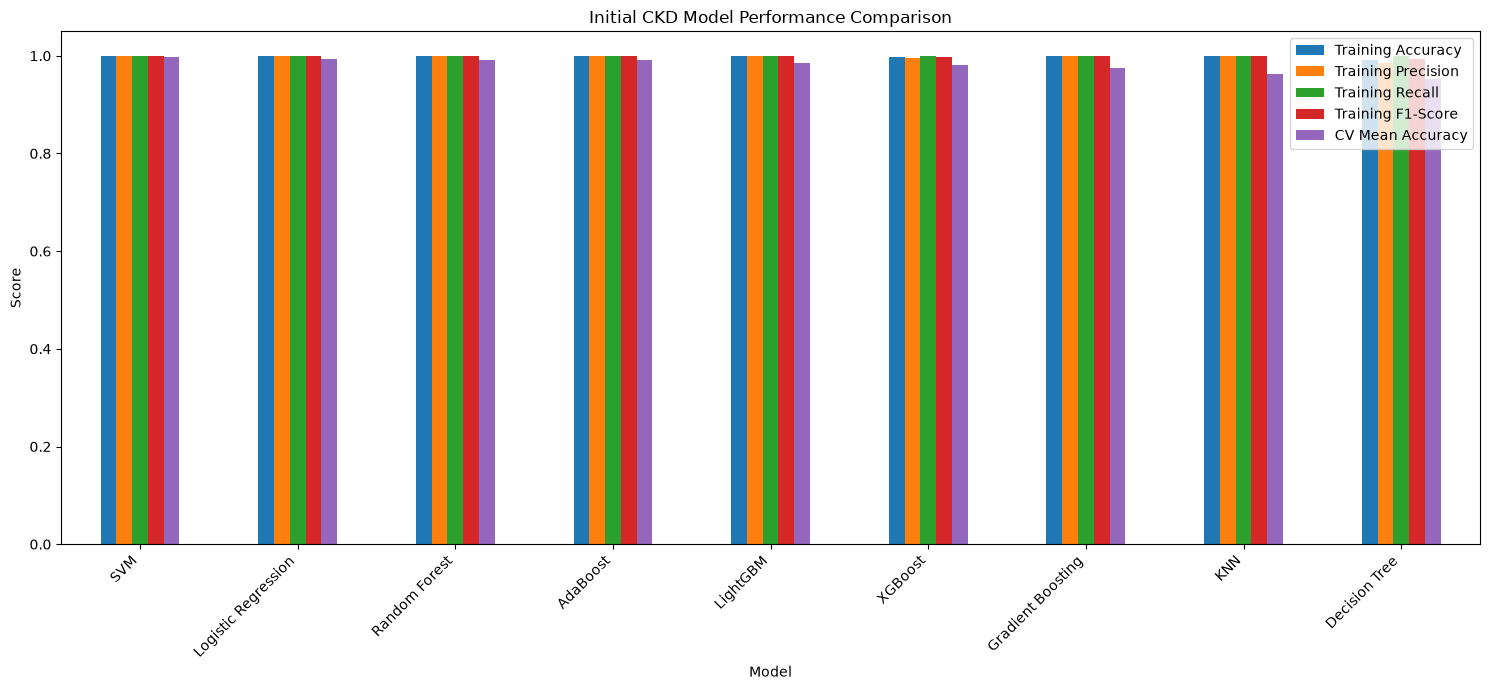

In [20]:
# 19. QUICK DASHBOARD PREVIEW

dashboard_metrics = [
    "Training Accuracy",
    "Training Precision",
    "Training Recall",
    "Training F1-Score",
    "CV Mean Accuracy"
]

plot_df = dashboard_df.set_index("Model")[dashboard_metrics]

ax = plot_df.plot(
    kind="bar",
    figsize=(15, 7)
)

ax.set_title("Initial CKD Model Performance Comparison")
ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 20. Save Results

In [21]:
# Save the model-building results for later notebooks/dashboard work.

# Prefer a results folder next to the notebooks folder.
results_dir = Path("../results")

# If that location is not writable/appropriate, fall back to /mnt/data.
try:
    results_dir.mkdir(parents=True, exist_ok=True)
except Exception:
    results_dir = Path("/mnt/data/CKD_results")
    results_dir.mkdir(parents=True, exist_ok=True)

comparison_file = results_dir / "model_building_comparison.csv"
dashboard_file = results_dir / "dashboard_model_results.csv"

comparison_df.to_csv(comparison_file, index=False)
dashboard_df.to_csv(dashboard_file, index=False)

print("Results saved successfully.")
print("Comparison:", comparison_file)
print("Dashboard data:", dashboard_file)

Results saved successfully.
Comparison: ..\results\model_building_comparison.csv
Dashboard data: ..\results\dashboard_model_results.csv


# Model Building Stage — Completed

### Completed
- Original CKD dataset loaded and verified
- 24 predictors separated from the target
- Target encoded as `ckd = 1`, `notckd = 0`
- Stratified 80:20 train-test split
- Leakage-safe preprocessing pipeline
- Nine model definitions
- Model training
- Training-set metrics
- 5-fold Stratified Cross-Validation
- Initial model comparison
- Generalization-gap warning
- Dashboard-ready CSV output

### Next Stage
**6. Hyperparameter Tuning**

After tuning, the project will proceed to:
**Evaluation → Model Comparison → Results & Discussion → Final Prediction/Demo → Final Dashboard.**
